- Curso: PPG em Genética e Biologia Molecular (PPGBM-UFPA)
- Disciplina: IA na Descoberta Genética
- Tema: Deep Learning para Genômica
- Docente: Helder Matos e Sintia Almeida

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 0. Preliminares

## 0.1. Knowledge Discovery in Databases (KDD)

KDD (*Knowledge Discovery in Databases*) é o processo de descobrir padrões em dados. Padrões válidos, novos, úteis e que fazem sentido para quem olha o resultado (FAYYAD et al., 1996).

É interativo: o analista intervém em cada etapa. E iterativo: o processo volta e refina etapas anteriores conforme o entendimento avança.

Cinco fases:

1. **Seleção**: escolher quais dados e variáveis entram na análise.
2. **Pré-processamento**: limpar ruído, tratar dados ausentes.
3. **Transformação**: formatar e armazenar os dados do jeito que a ferramenta de mineração espera.
4. **Mineração de dados**: buscar os padrões propriamente ditos.
5. **Interpretação e avaliação**: visualizar os padrões encontrados e checar se eles realmente aprenderam algo útil.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/kdd-process.png" alt="Processo KDD" width="100%">
</div>

# 1. Seleção

## 1.1. Carregamento dos dados

In [2]:
df_atac = pd.read_csv("data/tables/ATAC_peak_counts.csv")
df_atac

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter
0,S01,617,910,681,255,745,847
1,S02,681,710,711,244,714,805
2,S03,641,906,762,335,737,761
3,S04,684,833,665,293,836,689
4,S05,676,779,805,289,819,709
5,S06,764,875,596,384,728,734
6,S07,638,137,743,496,817,855
7,S08,670,171,726,589,688,684
8,S09,676,139,635,535,815,728
9,S10,645,171,739,538,915,784


In [3]:
df_genotypes = pd.read_csv("data/tables/genotypes.csv")
df_genotypes

,sample_id,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,S01,0,0,2,1
1,S02,1,0,0,0
2,S03,0,2,1,0
3,S04,0,0,0,0
4,S05,0,2,0,2
5,S06,2,0,1,2
6,S07,1,0,0,1
7,S08,1,1,0,0
8,S09,1,0,0,1
9,S10,0,1,1,2


In [4]:
df_metadata = pd.read_csv("data/tables/metadata.csv")
df_metadata

,sample_id,group,phenotype,sex,batch,age_years,notes
0,S01,Control,0,F,B1,34,baseline phenotype
1,S02,Control,0,M,B1,41,baseline phenotype
2,S03,Control,0,F,B1,29,baseline phenotype
3,S04,Control,0,M,B2,50,baseline phenotype
4,S05,Control,0,F,B2,38,baseline phenotype
5,S06,Control,0,M,B2,45,baseline phenotype
6,S07,Deficient,1,F,B1,36,reduced product of three-gene protein complex
7,S08,Deficient,1,M,B1,43,reduced product of three-gene protein complex
8,S09,Deficient,1,F,B1,31,reduced product of three-gene protein complex
9,S10,Deficient,1,M,B2,48,reduced product of three-gene protein complex


In [5]:
df_proteomics = pd.read_csv("data/tables/proteomics_intensity.csv")
df_proteomics

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,1134.33,1430.87,1053.74,481.60,1029.16,931.07
1,S02,1189.38,1232.65,1095.08,489.61,1039.74,960.05
2,S03,1289.34,1334.15,1146.85,487.02,1017.06,1077.44
3,S04,1290.23,1263.45,1095.92,561.81,973.28,989.07
4,S05,1278.27,1262.00,1061.68,529.04,998.58,1054.18
5,S06,1132.29,1392.68,1110.27,515.51,1040.04,1048.68
6,S07,1445.01,364.62,1159.84,1186.16,1056.43,982.24
7,S08,1404.72,360.33,1242.83,1001.16,968.70,985.71
8,S09,1153.27,372.82,1274.07,1162.20,1033.40,1023.61
9,S10,1204.00,373.63,1094.24,1051.27,1029.77,1130.74


In [6]:
df_rna = pd.read_csv("data/tables/RNA_counts.csv")
df_rna

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,996,1179,755,230,1086,1028
1,S02,967,1160,854,248,923,930
2,S03,991,990,672,295,1027,1144
3,S04,917,1267,802,275,1054,1089
4,S05,946,996,781,236,1002,807
5,S06,999,1059,878,250,993,957
6,S07,900,304,837,636,989,1154
7,S08,944,228,801,731,1076,905
8,S09,802,236,826,696,1149,1047
9,S10,1041,255,826,681,841,900


## 1.2. Integração multiômica

In [43]:
df = (
    df_atac
    .merge(df_genotypes, on="sample_id", how="inner", suffixes=("_atac", "_genotype"))
    .merge(df_metadata, on="sample_id", how="inner", suffixes=(None, "_metadata"))
    .merge(df_proteomics, on="sample_id", how="inner", suffixes=(None, "_proteomics"))
    .merge(df_rna, on="sample_id", how="inner", suffixes=("_proteomics", "_rna"))
)

df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


In [44]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype', 'sex',
       'batch', 'age_years', 'notes', 'GENA_proteomics', 'GENB_proteomics',
       'GENC_proteomics', 'GEND_proteomics', 'HK1_proteomics',
       'HK2_proteomics', 'GENA_rna', 'GENB_rna', 'GENC_rna', 'GEND_rna',
       'HK1_rna', 'HK2_rna'],
      dtype='str')

In [45]:
df_multiomic = pd.read_csv("data/tables/multiomics_ML_ready.csv")
df_multiomic

,sample_id,phenotype,group,batch,RNA_GENA,PROT_GENA,RNA_GENB,PROT_GENB,RNA_GENC,PROT_GENC,...,ATAC_GENA,ATAC_GENB,ATAC_GENC,ATAC_GEND,ATAC_HK1,ATAC_HK2,GT_rsToy1_GENA,GT_rsToy2_GENB,GT_rsToy3_GENC,GT_rsToy4_REG
0,S01,0,Control,B1,996,1134.33,1179,1430.87,755,1053.74,...,617,910,681,255,745,847,0,0,2,1
1,S02,0,Control,B1,967,1189.38,1160,1232.65,854,1095.08,...,681,710,711,244,714,805,1,0,0,0
2,S03,0,Control,B1,991,1289.34,990,1334.15,672,1146.85,...,641,906,762,335,737,761,0,2,1,0
3,S04,0,Control,B2,917,1290.23,1267,1263.45,802,1095.92,...,684,833,665,293,836,689,0,0,0,0
4,S05,0,Control,B2,946,1278.27,996,1262.00,781,1061.68,...,676,779,805,289,819,709,0,2,0,2
5,S06,0,Control,B2,999,1132.29,1059,1392.68,878,1110.27,...,764,875,596,384,728,734,2,0,1,2
6,S07,1,Deficient,B1,900,1445.01,304,364.62,837,1159.84,...,638,137,743,496,817,855,1,0,0,1
7,S08,1,Deficient,B1,944,1404.72,228,360.33,801,1242.83,...,670,171,726,589,688,684,1,1,0,0
8,S09,1,Deficient,B1,802,1153.27,236,372.82,826,1274.07,...,676,139,635,535,815,728,1,0,0,1
9,S10,1,Deficient,B2,1041,1204.00,255,373.63,826,1094.24,...,645,171,739,538,915,784,0,1,1,2


In [51]:
multiomic_columns = set(df_multiomic.columns.tolist())
integrated_columns = set(df.columns.tolist())

In [50]:
mapping_cols = {}

for col in multiomic_columns:
    multiomic_values = df_multiomic[col].to_list()
    for col2 in integrated_columns:
        integrated_values = df[col2].to_list()
        if multiomic_values == integrated_values:
            mapping_cols[col] = col2
            break
        mapping_cols[col] = "No match"

mapping_cols


{'GT_rsToy1_GENA': 'rsToy1_GENA',
 'PROT_HK1': 'HK1_proteomics',
 'GT_rsToy3_GENC': 'rsToy3_GENC',
 'RNA_GENC': 'GENC_rna',
 'sample_id': 'sample_id',
 'phenotype': 'phenotype',
 'RNA_HK2': 'HK2_rna',
 'ATAC_GENB': 'GENB_promoter',
 'batch': 'batch',
 'ATAC_GENA': 'GENA_promoter',
 'ATAC_HK2': 'HK2_promoter',
 'PROT_GEND': 'GEND_proteomics',
 'RNA_GEND': 'GEND_rna',
 'RNA_HK1': 'HK1_rna',
 'PROT_GENB': 'GENB_proteomics',
 'PROT_GENC': 'GENC_proteomics',
 'PROT_GENA': 'GENA_proteomics',
 'RNA_GENA': 'GENA_rna',
 'ATAC_GENC': 'GENC_promoter',
 'GT_rsToy2_GENB': 'rsToy2_GENB',
 'RNA_GENB': 'GENB_rna',
 'GT_rsToy4_REG': 'rsToy4_REG',
 'group': 'group',
 'ATAC_GEND': 'GEND_promoter',
 'PROT_HK2': 'HK2_proteomics',
 'ATAC_HK1': 'HK1_promoter'}

In [57]:
integrated_columns.difference(mapping_cols.values())

{'age_years', 'notes', 'sex'}

In [ ]:
df = df.drop(columns=[col for col in df.columns if col not in mapping_cols.values()])
df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


## 1.2. Análise exploratória dos dados

In [59]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype',
       'batch', 'GENA_proteomics', 'GENB_proteomics', 'GENC_proteomics',
       'GEND_proteomics', 'HK1_proteomics', 'HK2_proteomics', 'GENA_rna',
       'GENB_rna', 'GENC_rna', 'GEND_rna', 'HK1_rna', 'HK2_rna'],
      dtype='str')

In [ ]:
non_feature_cols = ["sample_id", "phenotype", "group", "batch"]
features = df.drop(columns=non_feature_cols).columns

In [60]:
df.describe()

,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000,12.000000
mean,661.416667,494.500000,697.166667,414.666667,778.083333,760.583333,0.583333,0.583333,0.583333,1.000000,...,1136.161667,807.363333,1009.481667,1002.091667,937.916667,687.666667,796.833333,465.250000,1029.75000,990.500000
std,40.971073,360.243478,60.671745,127.135814,72.817903,59.310368,0.668558,0.792961,0.792961,0.852803,...,67.106337,315.015892,34.678538,71.846587,69.331166,446.430964,55.106233,221.383717,88.13123,108.056803
min,610.000000,137.000000,596.000000,244.000000,679.000000,684.000000,0.000000,0.000000,0.000000,0.000000,...,1053.740000,481.600000,948.280000,856.110000,802.000000,228.000000,672.000000,230.000000,841.00000,807.000000
25%,637.250000,153.250000,656.750000,292.000000,724.500000,716.500000,0.000000,0.000000,0.000000,0.000000,...,1094.870000,509.035000,977.825000,976.692500,912.750000,272.250000,774.500000,249.500000,992.00000,903.750000
50%,657.500000,440.500000,696.000000,436.500000,780.000000,747.500000,0.500000,0.000000,0.000000,1.000000,...,1128.360000,781.485000,1023.110000,987.635000,945.000000,647.000000,801.500000,455.000000,1040.50000,992.000000
75%,677.250000,843.500000,740.000000,530.500000,823.250000,806.750000,1.000000,1.000000,1.000000,2.000000,...,1154.687500,1079.002500,1034.985000,1050.055000,992.250000,1084.250000,828.750000,683.250000,1078.50000,1057.500000
max,764.000000,910.000000,805.000000,589.000000,915.000000,855.000000,2.000000,2.000000,2.000000,2.000000,...,1274.070000,1186.160000,1056.430000,1130.740000,1041.000000,1267.000000,878.000000,731.000000,1149.00000,1154.000000


In [65]:
n_subfigures = len(df.columns) - 4
n_subfigures

22

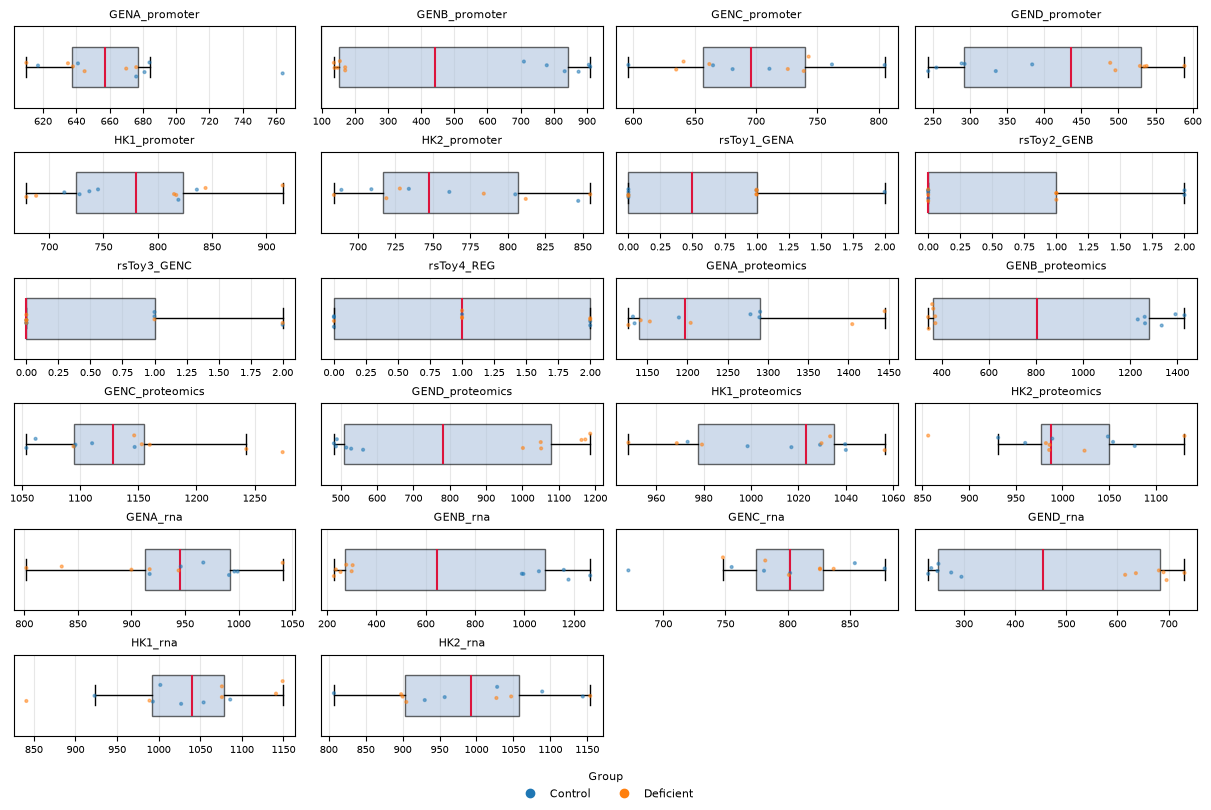

In [ ]:
groups = df['group'].dropna().unique()
palette = dict(zip(groups, plt.cm.tab10(np.arange(len(groups)))))

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(42)

for ax, col in zip(axes, features):
    sub = df[[col, 'group']].dropna(subset=[col])
    data = sub[col].values

    ax.boxplot(
        data, orientation='horizontal', widths=0.5, showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor='lightsteelblue', alpha=0.6),
        medianprops=dict(color='crimson', linewidth=1.5)
    )

    y = rng.normal(1, 0.06, size=len(data))
    ax.scatter(
        data, y, s=4, alpha=0.5,
        c=sub['group'].map(palette).tolist(), zorder=3
    )

    ax.set_title(col, fontsize=8)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

for ax in axes[len(features):]:
    ax.axis('off')

handles = []
for g in groups:
    handles.append(plt.Line2D([], [], marker='o', linestyle='', color=palette[g], markersize=6, label=str(g)))

fig.legend(
    handles=handles, title='Group', loc='outside lower center',
    ncol=len(groups), fontsize=8, title_fontsize=8, frameon=False
)

fig;

# 2. Pré-processamento

In [79]:
# valores ausentes

df.isnull().sum()

sample_id          0
GENA_promoter      0
GENB_promoter      0
GENC_promoter      0
GEND_promoter      0
HK1_promoter       0
HK2_promoter       0
rsToy1_GENA        0
rsToy2_GENB        0
rsToy3_GENC        0
rsToy4_REG         0
group              0
phenotype          0
batch              0
GENA_proteomics    0
GENB_proteomics    0
GENC_proteomics    0
GEND_proteomics    0
HK1_proteomics     0
HK2_proteomics     0
GENA_rna           0
GENB_rna           0
GENC_rna           0
GEND_rna           0
HK1_rna            0
HK2_rna            0
dtype: int64

# 3. Transformação

In [ ]:
X = df_multiomic.drop(columns=non_feature_cols)
y = df_multiomic["phenotype"]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")

Samples: 12, Features: 22


# 4. Mineração de dados

In [15]:
loo = LeaveOneOut()
y_pred = np.zeros_like(y)

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    y_pred[test_index] = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y, y_pred)}\n")
print(f"Confusion Matrix:\n{confusion_matrix(y, y_pred)}\n")
print(f"Classification Report: {classification_report(y, y_pred)}")

Accuracy: 1.0

Confusion Matrix:
[[6 0]
 [0 6]]

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



# 5. Interpretação e avaliação

# 6. Retorno à seleção

# 7. Simulador

# 8. Conclusão

# Referências